In [23]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization, Dropout, Dense
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [24]:
# Set the training directory
train_dir = "D:/AGRI AI/Data"

In [25]:
# Data augmentation and preparation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.4,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

In [26]:
# Training data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

Found 3442 images belonging to 5 classes.


In [27]:
# Validation data generators
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation'
)

Found 857 images belonging to 5 classes.


In [28]:
# Class labels
class_labels = list(train_generator.class_indices.keys())
num_classes = len(class_labels)
print(f'Classes found: {class_labels}')
print(f'Number of classes: {num_classes}')

Classes found: ['Anthracnose', 'Defect Dragon Fruit', 'Fresh Dragon Fruit', 'fruit_fly', 'healthy_guava']
Number of classes: 5


In [29]:
# Model definition
base_model = InceptionV3(include_top=False, weights='imagenet', input_shape=(224, 224, 3))

for layer in base_model.layers[:100]:
    layer.trainable = False

87910968/87910968 [==============================] - 20s 0us/step


In [30]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dropout(0.3),
    Dense(512, activation='relu', kernel_regularizer='l2'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(256, activation='relu', kernel_regularizer='l2'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

In [31]:
model.compile(
    optimizer=Adamax(learning_rate=5e-5, weight_decay=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [32]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inception_v3 (Functional)   (None, 5, 5, 2048)        21802784  
                                                                 
 global_average_pooling2d_2  (None, 2048)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 batch_normalization_100 (B  (None, 2048)              8192      
 atchNormalization)                                              
                                                                 
 dropout_6 (Dropout)         (None, 2048)              0         
                                                                 
 dense_6 (Dense)             (None, 512)               1049088   
                                                                 
 batch_normalization_101 (B  (None, 512)              

In [33]:
# Training the model
epochs = 50
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator,
    callbacks=[
        ModelCheckpoint("enhanced_fruit_disease_model.h5", save_best_only=True, monitor='val_accuracy', mode='max'),
        EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss'),
        ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6, monitor='val_loss')
    ]
)

Epoch 1/50
216/216 [==============================] - ETA: 0s - loss: 12.9956 - accuracy: 0.4843

c:\Users\DHANUSH KRISHNA\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


216/216 [==============================] - 400s 2s/step - loss: 12.9956 - accuracy: 0.4843 - val_loss: 12.1775 - val_accuracy: 0.7853 - lr: 5.0000e-05
Epoch 2/50
216/216 [==============================] - 361s 2s/step - loss: 12.3678 - accuracy: 0.6859 - val_loss: 11.9381 - val_accuracy: 0.8238 - lr: 5.0000e-05
Epoch 3/50
216/216 [==============================] - 416s 2s/step - loss: 12.1300 - accuracy: 0.7504 - val_loss: 11.7765 - val_accuracy: 0.8495 - lr: 5.0000e-05
Epoch 4/50
216/216 [==============================] - 432s 2s/step - loss: 11.9531 - accuracy: 0.7960 - val_loss: 11.7352 - val_accuracy: 0.8530 - lr: 5.0000e-05
Epoch 5/50
216/216 [==============================] - 433s 2s/step - loss: 11.8301 - accuracy: 0.8085 - val_loss: 11.5960 - val_accuracy: 0.8798 - lr: 5.0000e-05
Epoch 6/50
216/216 [==============================] - 451s 2s/step - loss: 11.7108 - accuracy: 0.8271 - val_loss: 11.5328 - val_accuracy: 0.8810 - lr: 5.0000e-05
Epoch 7/50
216/216 [===================

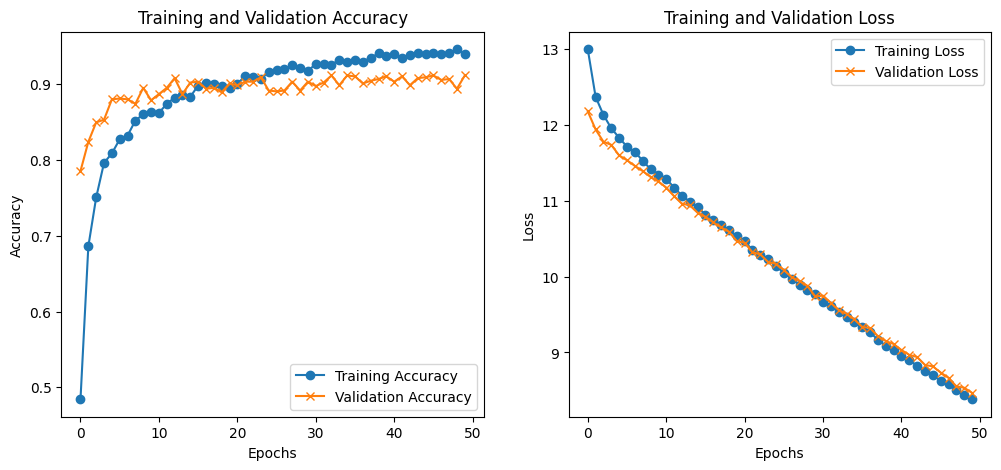

In [34]:
# Plotting training and validation accuracy and loss
import matplotlib.pyplot as plt

def plot_training_history(history):
    plt.figure(figsize=(12, 5))
    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss', marker='o')
    plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show(block=True)

plot_training_history(history)
